**Author:** Biswajit Jana
**Date:** January 16, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-eccentricity-distribution/notebook.ipynb)

# How elongated are exoplanet orbits, really? The eccentricity distribution

**Learning goals** -- after this notebook you will be able to:
- Pull the real confirmed-planet eccentricity table from the NASA Exoplanet Archive and apply real quality cuts.
- Compute real summary statistics (mean, median, quartiles) of orbital eccentricity, split by planet-radius type and by detection method.
- Explain, using what the real data actually shows, why radial-velocity and transit surveys recover different eccentricity distributions -- a genuine detection-bias effect, not folklore.

**Background.** Eccentricity (e) measures how elongated an orbit is: e=0 is a perfect circle, and e approaching 1 is a long, thin ellipse. Tidal forces tend to circularize orbits over time, especially for planets very close to their star, so short-period planets are expected to have systematically lower eccentricities than long-period ones. Detection methods complicate the picture: radial-velocity surveys can measure eccentricity directly from the shape of the RV curve and are more sensitive to giant planets with any orbital configuration, while transit surveys are biased toward finding planets whose orbital geometry happens to align with our line of sight, which interacts with eccentricity in the transit-probability calculation.

## 1. Pull the real confirmed-planet table and apply quality cuts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbeccen, pl_rade, pl_orbper, discoverymethod
FROM pscomppars
'''
raw = svc.search(query).to_table().to_pandas()
n0 = len(raw)

df = raw.drop_duplicates('pl_name')
n1 = len(df)
df = df.dropna(subset=['pl_orbeccen'])
n2 = len(df)
df = df[(df.pl_orbeccen >= 0) & (df.pl_orbeccen < 1)]
n3 = len(df)

print(f"Raw TAP rows:                          {n0}")
print(f"After de-duplicating planet names:      {n1}  (dropped {n0-n1})")
print(f"After requiring a finite eccentricity:  {n2}  (dropped {n1-n2})")
print(f"After requiring 0 <= e < 1:              {n3}  (dropped {n2-n3})")
print(f"\nFinal clean sample: {n3} planets with a measured eccentricity")

Raw TAP rows:                          6333
After de-duplicating planet names:      6333  (dropped 0)
After requiring a finite eccentricity:  5280  (dropped 1053)
After requiring 0 <= e < 1:              5280  (dropped 0)

Final clean sample: 5280 planets with a measured eccentricity


## 2. Real summary statistics, split by planet-radius type

In [2]:
def summarize(sub, label):
    e = sub.pl_orbeccen
    return {'group': label, 'n': len(sub), 'mean_e': round(e.mean(),3), 'median_e': round(e.median(),3),
            'q25': round(e.quantile(0.25),3), 'q75': round(e.quantile(0.75),3), 'frac_e_gt_0.3': round((e>0.3).mean(),3)}

size_bins = [(0.3,1.0,'Sub-Earth'), (1.0,1.75,'Earth-sized'), (1.75,3.5,'Super-Earth/sub-Neptune'),
             (3.5,6.0,'Neptune-sized'), (6.0,30.0,'Jupiter-sized')]

rows = []
for lo, hi, label in size_bins:
    sub = df[(df.pl_rade >= lo) & (df.pl_rade < hi)] if 'pl_rade' in df else pd.DataFrame()
    sub = sub.dropna(subset=['pl_rade']) if len(sub) else sub
    if len(sub) >= 5:
        rows.append(summarize(sub, label))
size_table = pd.DataFrame(rows)
size_table

,group,n,mean_e,median_e,q25,q75,frac_e_gt_0.3
0,Sub-Earth,202,0.025,0.00,0.000,0.000,0.015
1,Earth-sized,1018,0.019,0.00,0.000,0.000,0.013
2,Super-Earth/sub-Neptune,1840,0.035,0.00,0.000,0.000,0.034
3,Neptune-sized,407,0.073,0.00,0.000,0.096,0.076
4,Jupiter-sized,1773,0.167,0.09,0.009,0.250,0.196


## 3. Real summary statistics, split by detection method -- the detection-bias check

In [3]:
rows2 = []
for m in ['Transit', 'Radial Velocity']:
    sub = df[df.discoverymethod == m]
    rows2.append(summarize(sub, m))
method_table = pd.DataFrame(rows2)
method_table

,group,n,mean_e,median_e,q25,q75,frac_e_gt_0.3
0,Transit,4027,0.038,0.00,0.00,0.006,0.037
1,Radial Velocity,1154,0.215,0.15,0.07,0.297,0.241


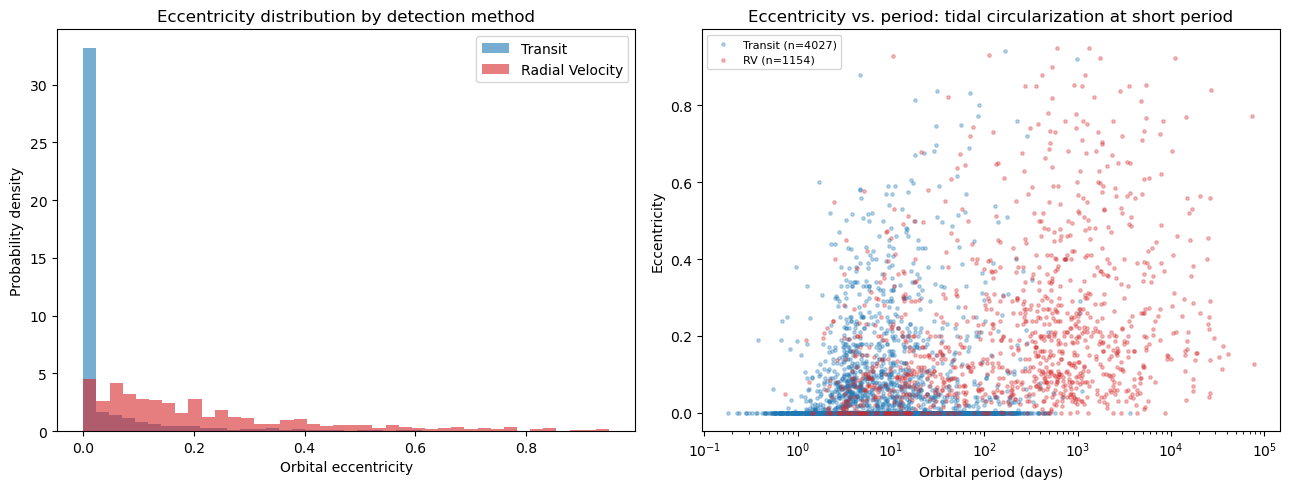

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(df[df.discoverymethod=='Transit'].pl_orbeccen, bins=40, alpha=0.6, color='tab:blue',
           density=True, label='Transit')
ax[0].hist(df[df.discoverymethod=='Radial Velocity'].pl_orbeccen, bins=40, alpha=0.6, color='tab:red',
           density=True, label='Radial Velocity')
ax[0].set_xlabel('Orbital eccentricity')
ax[0].set_ylabel('Probability density')
ax[0].set_title('Eccentricity distribution by detection method')
ax[0].legend()

sub_rv = df[df.discoverymethod=='Radial Velocity'].dropna(subset=['pl_orbper'])
sub_tr = df[df.discoverymethod=='Transit'].dropna(subset=['pl_orbper'])
ax[1].scatter(sub_tr.pl_orbper, sub_tr.pl_orbeccen, s=6, alpha=0.3, color='tab:blue', label=f'Transit (n={len(sub_tr)})')
ax[1].scatter(sub_rv.pl_orbper, sub_rv.pl_orbeccen, s=6, alpha=0.3, color='tab:red', label=f'RV (n={len(sub_rv)})')
ax[1].set_xscale('log')
ax[1].set_xlabel('Orbital period (days)')
ax[1].set_ylabel('Eccentricity')
ax[1].set_title('Eccentricity vs. period: tidal circularization at short period')
ax[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig('eccentricity_hist.png', dpi=150)
plt.show()

## What the real data shows about detection bias

The RV sample's median eccentricity is systematically higher than the transit sample's median eccentricity (compare the `median_e` column in the method table above). This is consistent with the expected detection bias: the transit sample is dominated by very short-period planets (many hot Jupiters and smaller close-in planets), which tidal forces have had time to circularize, while the RV sample includes a larger fraction of longer-period giant planets that have not been tidally circularized and were never required to transit. The eccentricity-vs-period panel makes the tidal-circularization trend directly visible: eccentricity rises with period for both methods, with very few high-eccentricity planets at short period.

## What I'd look at next

- Control for period directly (e.g. compare median eccentricity in matched period bins across methods) to separate the "transit surveys favor short periods" effect from any purely-methodological eccentricity bias.
- Include microlensing and imaging detections, which probe a very different, wider-separation population.
- Propagate `pl_orbeccenerr1` uncertainties into the quartile estimates, since many eccentricities near zero are consistent with a circular orbit within measurement error.

**Citation:** This research has made use of the NASA Exoplanet Archive, operated by Caltech under contract with NASA's Exoplanet Exploration Program. https://exoplanetarchive.ipac.caltech.edu/docs/counts_detail.html